In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df=pd.read_csv("A:\Dataset\phishing_site_urls.csv")

In [6]:
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [7]:
df.shape

(549346, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [9]:
df.isnull().sum()

URL      0
Label    0
dtype: int64

In [11]:
df.Label.value_counts()

Label
good    392924
bad     156422
Name: count, dtype: int64

In [12]:
from nltk.tokenize import RegexpTokenizer

In [13]:
tokenizer=RegexpTokenizer(r'[A-Za-z]+')

In [15]:
df.URL[0]

'nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526'

In [16]:
tokenizer.tokenize(df.URL[0])

['nobell',
 'it',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'login',
 'SkyPe',
 'com',
 'en',
 'cgi',
 'bin',
 'verification',
 'login',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'index',
 'php',
 'cmd',
 'profile',
 'ach',
 'outdated',
 'page',
 'tmpl',
 'p',
 'gen',
 'failed',
 'to',
 'load',
 'nav',
 'login',
 'access']

In [17]:
df['text_tokenized']=df.URL.map(lambda t: tokenizer.tokenize(t))

In [18]:
df.head()

,URL,Label,text_tokenized
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi..."


In [19]:
from nltk.stem.snowball import SnowballStemmer

In [20]:
stemmer=SnowballStemmer('english')

In [22]:
df['text_stemmed']=df['text_tokenized'].map(lambda l:[stemmer.stem(word)for word in l])

In [23]:
df.head()

,URL,Label,text_tokenized,text_stemmed
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide..."


In [24]:
df['text']=df['text_stemmed'].map(lambda l:' '.join(l))

### Model Train

In [25]:
good_sites=df[df.Label=='good']
bad_sites=df[df.Label=='bad']

In [26]:
good_sites.head()

,URL,Label,text_tokenized,text_stemmed,text
18231,esxcc.com/js/index.htm?us.battle.net/noghn/en/...,good,"[esxcc, com, js, index, htm, us, battle, net, ...","[esxcc, com, js, index, htm, us, battl, net, n...",esxcc com js index htm us battl net noghn en r...
18232,wwweira¯&nvinip¿ncH¯wVö%ÆåyDaHðû/ÏyEùuË\nÓ6...,good,"[www, eira, nvinip, ncH, wV, yDaH, yE, u, rT, ...","[www, eira, nvinip, nch, wv, ydah, ye, u, rt, ...",www eira nvinip nch wv ydah ye u rt u g m i xz...
18233,'www.institutocgr.coo/web/media/syqvem/dk-óij...,good,"[www, institutocgr, coo, web, media, syqvem, d...","[www, institutocgr, coo, web, media, syqvem, d...",www institutocgr coo web media syqvem dk ij r ...
18234,Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,good,"[Y, ko, D, l, qt]","[y, ko, d, l, qt]",y ko d l qt
18236,ruta89fm.com/images/AS@Vies/1i75cf7b16vc<Fd16...,good,"[ruta, fm, com, images, AS, Vies, i, cf, b, vc...","[ruta, fm, com, imag, as, vie, i, cf, b, vc, f...",ruta fm com imag as vie i cf b vc f d b g sd v...


In [27]:
def plot_wordcloud(text, mask=None, max_words=400, max_font_size=120,
                   figure_size=(24.0, 16.0), title=None, title_size=40,
                   image_color=False):

    stopwords = set(STOPWORDS)
    more_stopwords = {'com', 'http'}
    stopwords = stopwords.union(more_stopwords)

    wordcloud = WordCloud(
        background_color='white',
        stopwords=stopwords,
        max_words=max_words,
        max_font_size=max_font_size,
        random_state=42,
        mask=mask
    ).generate(text)

    plt.figure(figsize=figure_size)

    if image_color and mask is not None:
        image_colors = ImageColorGenerator(mask)
        plt.imshow(wordcloud.recolor(color_func=image_colors),
                   interpolation="bilinear")
        plt.title(title, fontsize=title_size, verticalalignment='bottom')

    else:
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.title(title, fontsize=title_size, color='green',
                  verticalalignment='bottom')

    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [29]:
all_text=' '.join(good_sites['text'].tolist())

In [42]:
!pip install WordCloud


Defaulting to user installation because normal site-packages is not writeable


In [46]:
import sys
print(sys.executable)


A:\Anaconda\python.exe


In [49]:
 conda activate base



Note: you may need to restart the kernel to use updated packages.



CondaError: Run 'conda init' before 'conda activate'



In [50]:
conda install -c conda-forge wordcloud


Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done

Note: you may need to restart the kernel to use updated packages.



EnvironmentNotWritableError: The current user does not have write permissions to the target environment.
  environment location: A:\Anaconda




In [51]:
from wordcloud import WordCloud

ModuleNotFoundError: No module named 'wordcloud'

In [52]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


NameError: name 'WordCloud' is not defined

In [53]:
from sklearn.feature_extraction.text import CountVectorizer

In [55]:
cv=CountVectorizer()

In [56]:
features=cv.fit_transform(df.text)

In [58]:
features[:5].toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5, 350837))

In [59]:
from sklearn.model_selection import train_test_split

In [61]:
x_train,x_test,y_train,y_test=train_test_split(features,df.Label,test_size=0.2)

In [63]:
from sklearn.linear_model import LogisticRegression

In [66]:
l_model=LogisticRegression()

In [67]:
l_model.fit(x_train,y_train)

A:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [68]:
l_model.score(x_test,y_test)

0.9646946391189588

In [69]:
l_model.score(x_train,y_train)

0.9786723279542

In [70]:
from sklearn.metrics import classification_report

print("\nCLASSIFICATION REPORT\n")

y_pred = l_model.predict(x_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=['Bad', 'Good']
))



CLASSIFICATION REPORT

              precision    recall  f1-score   support

         Bad       0.97      0.91      0.94     31407
        Good       0.96      0.99      0.98     78463

    accuracy                           0.96    109870
   macro avg       0.97      0.95      0.96    109870
weighted avg       0.96      0.96      0.96    109870



In [71]:
from sklearn.metrics import confusion_matrix

In [72]:
con_mat = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    columns=['Predicted:Bad', 'Predicted:Good'],
    index=['Actual:Bad', 'Actual:Good']
)

In [73]:
import seaborn as sns


CONFUSION MATRIX


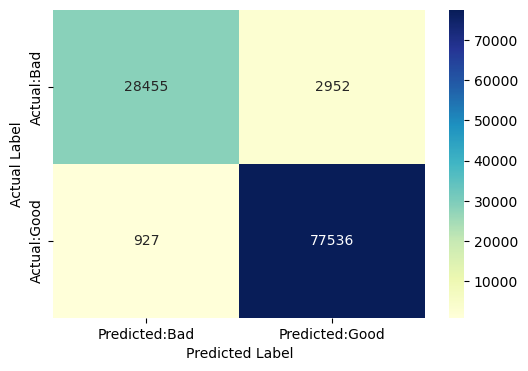

In [74]:
print("\nCONFUSION MATRIX")

plt.figure(figsize=(6, 4))
sns.heatmap(con_mat, annot=True, fmt='d', cmap='YlGnBu')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


In [75]:
from sklearn.naive_bayes import MultinomialNB

In [76]:
mnb=MultinomialNB()

In [77]:
mnb.fit(x_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [78]:
mnb.score(x_test,y_test)

0.9587239464822063

### Save Model

In [79]:
import pickle

In [80]:
pickle.dump(l_model,open('phishing.pkl','wb'))

In [83]:
pickle.dump(cv,open('vectorizer.pkl' , 'wb'))

In [84]:
predict_bad=['yeniik.com.tr/wp-admin/js/login.alibaba.com/login.jsp.php',
'fazan-pacir.rs/temp/libraries/ipad',
'www.tubemoviez.exe',
'svision-online.de/mgfi/administrator/components/com_babackup/classes/fx29id1.txt']
predict_good=['www.youtube.com/',
'youtube.com/watch?v=qI0TQJI3vdU',
'www.retailhellunderground.com/',
'restorevisioncenters.com/html/technology.html'
]